In [2]:
#PHASE 1: Data Collection
import pandas as pd
import numpy as np

data = {
    "From": ["Warehouse","Warehouse","ISBT","ISBT","Clock Tower","Clock Tower",
             "Rajpur Road","ONGC Chowk","Race Course","Clement Town",
             "Prem Nagar","Sahastradhara"],
    
    "To": ["ISBT","Clement Town","Clock Tower","Race Course","Rajpur Road","ONGC Chowk",
           "Sahastradhara","Pacific Mall","Pacific Mall","ISBT",
           "ONGC Chowk","Pacific Mall"],
    
    "Road_Distance_km": [2,3,4,3,3,2,5,4,5,2,6,3],
    
    "Traffic_Level": ["Low","Medium","High",np.nan,"Medium","Low","High","Medium","High","Low","Medium",np.nan],
    
    "Avg_Speed_kmph": [40,35,20,30,25,40,18,np.nan,22,45,28,40],
    
    "Delivery_Time_min": [8,np.nan,15,10,12,6,20,14,np.nan,5,18,9],
    
    "Euclidean_Distance": [6.4,6.3,2.2,4.0,2.2,3.1,3.1,0,0,6.4,6.0,3.1],
    
    "Weather_Impact": [0,1,2,1,np.nan,0,2,1,2,0,np.nan,0]
}

df = pd.DataFrame(data)
print(df)

             From             To  Road_Distance_km Traffic_Level  \
0       Warehouse           ISBT                 2           Low   
1       Warehouse   Clement Town                 3        Medium   
2            ISBT    Clock Tower                 4          High   
3            ISBT    Race Course                 3           NaN   
4     Clock Tower    Rajpur Road                 3        Medium   
5     Clock Tower     ONGC Chowk                 2           Low   
6     Rajpur Road  Sahastradhara                 5          High   
7      ONGC Chowk   Pacific Mall                 4        Medium   
8     Race Course   Pacific Mall                 5          High   
9    Clement Town           ISBT                 2           Low   
10     Prem Nagar     ONGC Chowk                 6        Medium   
11  Sahastradhara   Pacific Mall                 3           NaN   

    Avg_Speed_kmph  Delivery_Time_min  Euclidean_Distance  Weather_Impact  
0             40.0                8.0  

In [3]:
#PHASE 2: EDA (Data Cleaning + Analysis)
# Handling missing values (NO WARNING)
df["Avg_Speed_kmph"] = df["Avg_Speed_kmph"].fillna(df["Avg_Speed_kmph"].mean())
df["Delivery_Time_min"] = df["Delivery_Time_min"].fillna(df["Delivery_Time_min"].mean())
df["Traffic_Level"] = df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0])
df["Weather_Impact"] = df["Weather_Impact"].fillna(df["Weather_Impact"].mode()[0])

# Encode categorical
df["Traffic_Level"] = df["Traffic_Level"].map({"Low":1,"Medium":2,"High":3})

# Basic EDA
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nNull Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   From                12 non-null     object 
 1   To                  12 non-null     object 
 2   Road_Distance_km    12 non-null     int64  
 3   Traffic_Level       12 non-null     int64  
 4   Avg_Speed_kmph      12 non-null     float64
 5   Delivery_Time_min   12 non-null     float64
 6   Euclidean_Distance  12 non-null     float64
 7   Weather_Impact      12 non-null     float64
dtypes: float64(4), int64(2), object(2)
memory usage: 900.0+ bytes
None

Summary Statistics:
       Road_Distance_km  Traffic_Level  Avg_Speed_kmph  Delivery_Time_min  \
count         12.000000      12.000000       12.000000          12.000000   
mean           3.500000       2.000000       31.181818          11.700000   
std            1.314257       0.738549        8.901667           4.53


Optimal Path: Warehouse → ISBT → Race Course → Pacific Mall
Total Cost: 1.253
Nodes Explored: 6


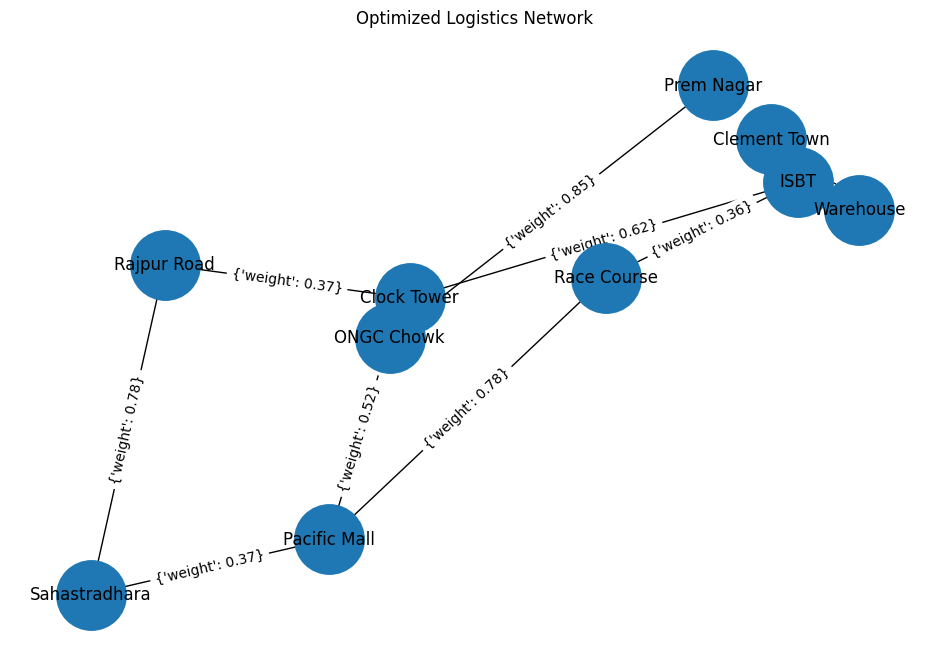

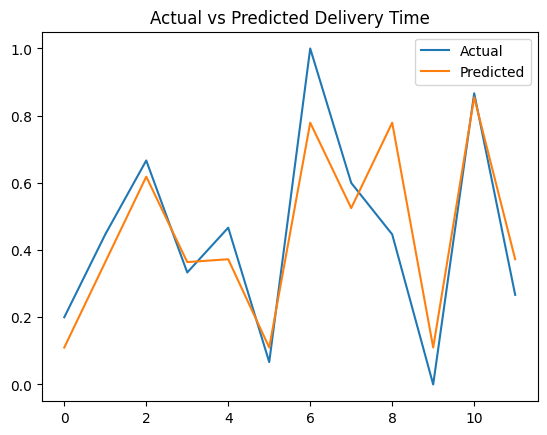

In [6]:
#PHASE 3: Model Training (ML + A Algorithm)*
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# Scaling
scaler = MinMaxScaler()
df[["Road_Distance_km","Avg_Speed_kmph","Delivery_Time_min","Euclidean_Distance"]] = scaler.fit_transform(
    df[["Road_Distance_km","Avg_Speed_kmph","Delivery_Time_min","Euclidean_Distance"]]
)

# ML Model
X = df[["Road_Distance_km","Traffic_Level","Weather_Impact"]]
y = df["Delivery_Time_min"]

model = LinearRegression()
model.fit(X, y)

df["Predicted_Time"] = model.predict(X)
import heapq

# Graph creation
graph = {}
for _, row in df.iterrows():
    if row["From"] not in graph:
        graph[row["From"]] = []
    graph[row["From"]].append((row["To"], row["Predicted_Time"]))

# Heuristic
heuristic = {}
for _, row in df.iterrows():
    heuristic[row["From"]] = row["Euclidean_Distance"]

# A* Algorithm
def astar(graph, start, goal, heuristic):
    pq = [(0, start)]
    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0
    
    parent = {}
    nodes_explored = 0
    
    while pq:
        f, current = heapq.heappop(pq)
        nodes_explored += 1
        
        if current == goal:
            break
        
        for neighbor, cost in graph.get(current, []):
            new_g = g_cost[current] + cost
            
            if new_g < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor] = new_g
                f_cost = new_g + heuristic.get(neighbor, 0)
                
                heapq.heappush(pq, (f_cost, neighbor))
                parent[neighbor] = current
    
    path = []
    node = goal
    
    while node != start:
        path.append(node)
        node = parent.get(node)
        if node is None:
            return "No Path", None, None
    
    path.append(start)
    path.reverse()
    
    return path, g_cost[goal], nodes_explored

# Run
start = "Warehouse"
goal = "Pacific Mall"

result = astar(graph, start, goal, heuristic)

print("\nOptimal Path:", " → ".join(result[0]))
print("Total Cost:", round(result[1],3))
print("Nodes Explored:", result[2])


import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in df.iterrows():
    G.add_edge(row["From"], row["To"], weight=round(row["Predicted_Time"],2))

pos = nx.kamada_kawai_layout(G)

plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(G, pos, node_size=2500)
nx.draw_networkx_edges(G, pos, arrowstyle='->')
nx.draw_networkx_labels(G, pos)
nx.draw_networkx_edge_labels(G, pos)

plt.title("Optimized Logistics Network")
plt.axis('off')
plt.show()

plt.figure()
plt.plot(df["Delivery_Time_min"], label="Actual")
plt.plot(df["Predicted_Time"], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Delivery Time")
plt.show()